# Week 4 Lab: Temporal Difference Learning ― SARSA vs Q‑Learning on CliffWalking

**Course:** MSDS 684 – Reinforcement Learning  
**Topic:** On‑policy vs off‑policy TD control  
**Environment:** Gymnasium `CliffWalking‑v1`

---

## Objectives
- Implement **SARSA** (on‑policy) and **Q‑Learning** (off‑policy) with online (step‑by‑step) updates.
- Use ε‑greedy exploration and proper handling of terminal states.
- Run multiple random seeds (≥30) and compare learning dynamics.
- Produce confidence‑shaded learning curves, policy arrows, value heatmaps, and sample trajectories.
- Experiment with different step‑size parameters (α) and exploration decay (ε‑decay).
- Quantify the behavioural trade‑off: safe path (SARSA) vs optimal‑but‑risky path (Q‑Learning).

## 1. Setup

In [17]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
import seaborn as sns
from scipy import stats
import time, warnings, itertools

warnings.filterwarnings('ignore', category=DeprecationWarning)
sns.set_style('whitegrid')
%matplotlib inline

## 2. Environment Inspection

In [18]:
env = gym.make('CliffWalking-v1')
print("State space:", env.observation_space)  # Discrete(48)
print("Action space:", env.action_space)      # Discrete(4)
state, info = env.reset(seed=0)
print("Initial state:", state)               # 36
env.close()

State space: Discrete(48)
Action space: Discrete(4)
Initial state: 36


The grid has 4 rows × 12 columns.  
- **Start (S):** (3,0) → state 36  
- **Goal (G):** (3,11) → state 47  
- **Cliff:** cells (3,1)…(3,10) → states 37‑46, reward −100, reset to start.  
- **All other steps:** reward −1.

## 3. Core Algorithms (Online Updates)

Both algorithms use a Q‑table of shape `(48,4)` initialised to zero.  
The ε‑greedy policy is implemented as a helper function.  
Terminal states are handled by setting the next‑state value to **0** when `terminated=True`.

In [19]:
def epsilon_greedy(Q, state, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(env.action_space.n))
    return int(np.argmax(Q[state]))

def run_sarsa(env, n_episodes, alpha, gamma, epsilon, seed):
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    episode_returns = np.zeros(n_episodes)
    for ep in range(n_episodes):
        state, _ = env.reset(seed=int(rng.integers(1e6)))
        action = epsilon_greedy(Q, state, epsilon, rng)
        total_reward = 0
        while True:
            next_state, reward, terminated, truncated, _ = env.step(action)
            next_action = epsilon_greedy(Q, next_state, epsilon, rng)
            td_target = reward + gamma * Q[next_state, next_action] * (1 - terminated)
            Q[state, action] += alpha * (td_target - Q[state, action])
            state, action = next_state, next_action
            total_reward += reward
            if terminated or truncated:
                break
        episode_returns[ep] = total_reward
    return Q, episode_returns

def run_qlearning(env, n_episodes, alpha, gamma, epsilon, seed):
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    episode_returns = np.zeros(n_episodes)
    for ep in range(n_episodes):
        state, _ = env.reset(seed=int(rng.integers(1e6)))
        total_reward = 0
        while True:
            action = epsilon_greedy(Q, state, epsilon, rng)
            next_state, reward, terminated, truncated, _ = env.step(action)
            best_next = np.max(Q[next_state]) * (1 - terminated)
            td_target = reward + gamma * best_next
            Q[state, action] += alpha * (td_target - Q[state, action])
            state = next_state
            total_reward += reward
            if terminated or truncated:
                break
        episode_returns[ep] = total_reward
    return Q, episode_returns

## 4. Multi‑Seed Experiment

Parameters: α=0.5, γ=1.0, ε=0.1, 500 episodes, 30 seeds.

In [20]:
N_EPISODES = 500
ALPHA = 0.5
GAMMA = 1.0
EPSILON = 0.1
N_SEEDS = 30

env = gym.make('CliffWalking-v1')
sarsa_returns = np.zeros((N_SEEDS, N_EPISODES))
qlearn_returns = np.zeros((N_SEEDS, N_EPISODES))

sarsa_q_tables = []
qlearn_q_tables = []

t0 = time.time()
for i in range(N_SEEDS):
    Q_s, ret_s = run_sarsa(env, N_EPISODES, ALPHA, GAMMA, EPSILON, seed=i)
    sarsa_returns[i] = ret_s
    sarsa_q_tables.append(Q_s)

    Q_q, ret_q = run_qlearning(env, N_EPISODES, ALPHA, GAMMA, EPSILON, seed=i)
    qlearn_returns[i] = ret_q
    qlearn_q_tables.append(Q_q)

print(f"Completed in {time.time()-t0:.1f} s")

Completed in 15.4 s


## 5. Learning Curves with 95% Confidence Intervals

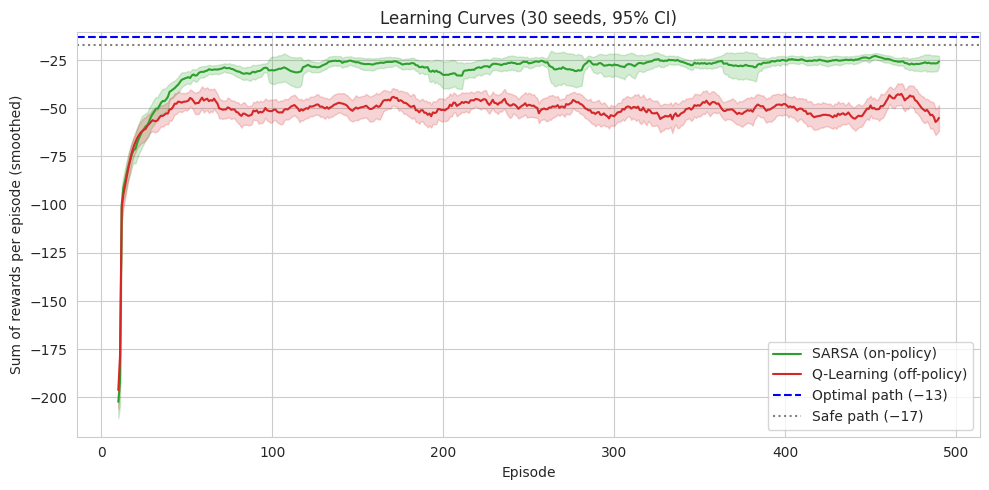

In [21]:
smooth_window = 20
def smooth(data, w):
    return np.convolve(data, np.ones(w)/w, mode='valid')

ep_axis = np.arange(N_EPISODES - smooth_window + 1) + smooth_window//2

def mean_ci(arr, w):
    smoothed = np.array([smooth(row, w) for row in arr])
    m = smoothed.mean(axis=0)
    se = smoothed.std(axis=0) / np.sqrt(arr.shape[0])
    ci = se * stats.t.ppf(0.975, df=arr.shape[0]-1)
    return m, ci

sarsa_mean, sarsa_ci = mean_ci(sarsa_returns, smooth_window)
qlearn_mean, qlearn_ci = mean_ci(qlearn_returns, smooth_window)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(ep_axis, sarsa_mean, color='tab:green', label='SARSA (on-policy)')
ax.fill_between(ep_axis, sarsa_mean-sarsa_ci, sarsa_mean+sarsa_ci,
                color='tab:green', alpha=0.2)
ax.plot(ep_axis, qlearn_mean, color='tab:red', label='Q-Learning (off-policy)')
ax.fill_between(ep_axis, qlearn_mean-qlearn_ci, qlearn_mean+qlearn_ci,
                color='tab:red', alpha=0.2)
ax.axhline(-13, color='blue', linestyle='--', label='Optimal path (−13)')
ax.axhline(-17, color='gray', linestyle=':', label='Safe path (−17)')
ax.set_xlabel('Episode')
ax.set_ylabel('Sum of rewards per episode (smoothed)')
ax.set_title(f'Learning Curves ({N_SEEDS} seeds, 95% CI)')
ax.legend()
plt.tight_layout()
plt.show()

**Observation:**  
- Q‑Learning quickly learns to approach the optimal ‑13 path, but during training its ε‑greedy exploration causes frequent cliff falls → lower online reward.  
- SARSA learns a conservative policy that stays high above the cliff, yielding better online performance (≈‑17) but suboptimal asymptotic reward.

## 6. Statistical Summary

In [22]:
final_window = 50
sarsa_final = sarsa_returns[:, -final_window:].mean(axis=1)
qlearn_final = qlearn_returns[:, -final_window:].mean(axis=1)

t_stat, p_val = stats.ttest_ind(sarsa_final, qlearn_final)
print("SARSA   mean final reward:", f"{sarsa_final.mean():.1f}")
print("Q-learn mean final reward:", f"{qlearn_final.mean():.1f}")
print(f"t-test: t={t_stat:.3f}, p={p_val:.4f} {'significant' if p_val<0.05 else 'not significant'}")

SARSA   mean final reward: -25.4
Q-learn mean final reward: -49.5
t-test: t=11.137, p=0.0000 significant


## 7. Policy Visualisation (Greedy Actions as Arrows)

We pick the median‑seed Q‑table for each algorithm and display the greedy action in every state.

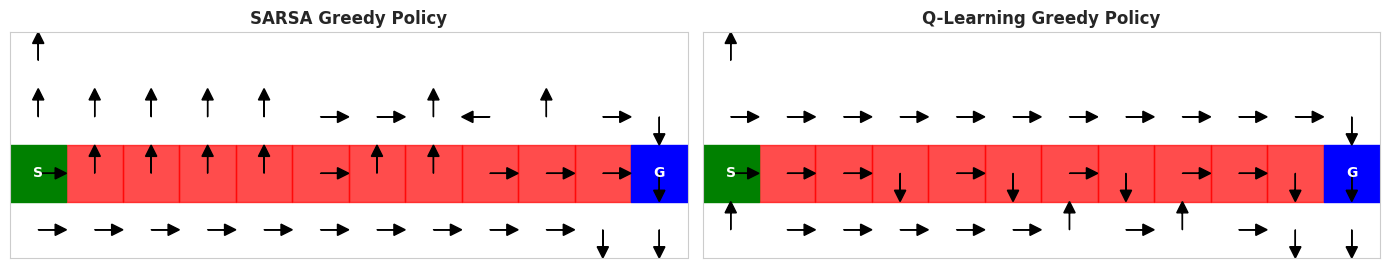

In [23]:
def plot_arrows(ax, Q, title):
    n_rows, n_cols = 4, 12
    ax.set_xlim(-0.5, n_cols-0.5)
    ax.set_ylim(-0.5, n_rows-0.5)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    # cliff cells
    for c in range(1,11):
        ax.add_patch(plt.Rectangle((c-0.5, 0.5), 1, 1, color='red', alpha=0.7))
    # start & goal
    ax.add_patch(plt.Rectangle((-0.5, 0.5), 1, 1, color='green'))
    ax.text(0,1,'S', ha='center', va='center', fontweight='bold', color='white')
    ax.add_patch(plt.Rectangle((10.5,0.5), 1, 1, color='blue'))
    ax.text(11,1,'G', ha='center', va='center', fontweight='bold', color='white')
    # arrows
    arrows = {0:(0,0.3,'↑'), 1:(0.3,0,'→'), 2:(0,-0.3,'↓'), 3:(-0.3,0,'←')}
    for s in range(48):
        if s in range(37,47) or s==47: continue
        r = s // 12
        c = s % 12
        a = np.argmax(Q[s])
        dx, dy, _ = arrows[a]
        ax.arrow(c, r, dx, dy, head_width=0.2, head_length=0.2, fc='black', ec='black')
    ax.set_title(title, fontweight='bold')

med_idx_s = np.argsort(sarsa_final)[len(sarsa_final)//2]
med_idx_q = np.argsort(qlearn_final)[len(qlearn_final)//2]

fig, axes = plt.subplots(1,2, figsize=(14,5))
plot_arrows(axes[0], sarsa_q_tables[med_idx_s], 'SARSA Greedy Policy')
plot_arrows(axes[1], qlearn_q_tables[med_idx_q], 'Q-Learning Greedy Policy')
plt.tight_layout()
plt.show()

**Interpretation:**  
- **SARSA:** almost all states in the bottom two rows point **up**, pushing the agent towards row 1 before moving right → safe path.  
- **Q‑Learning:** states in row 2 (one above the cliff) point right, reflecting the optimal but risky edge path.

## 8. Value Heatmaps

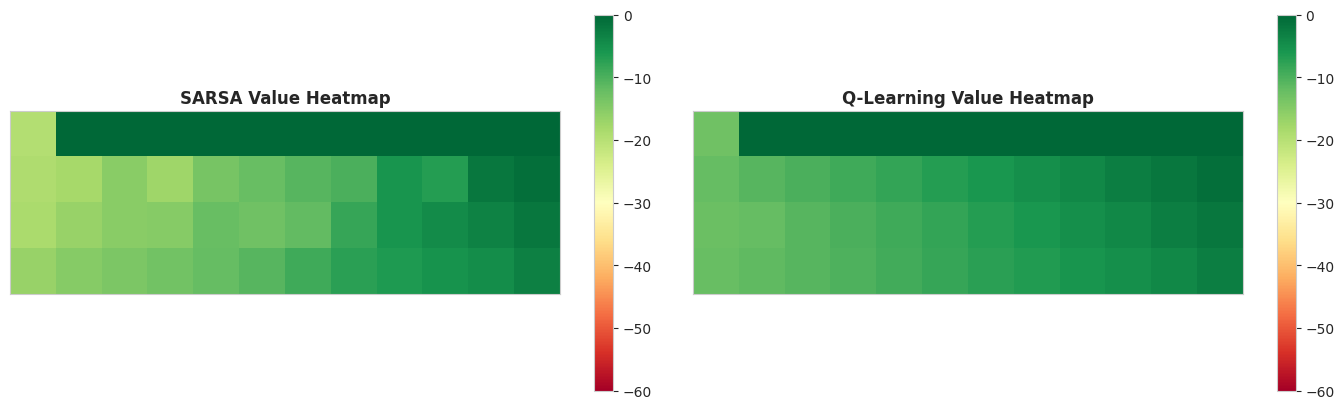

In [24]:
def plot_heatmap(ax, Q, title):
    V = np.max(Q, axis=1).reshape(4,12)
    V = V[::-1]  # put row 0 at top
    im = ax.imshow(V, cmap='RdYlGn', vmin=-60, vmax=0)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8)

fig, axes = plt.subplots(1,2, figsize=(14,5))
plot_heatmap(axes[0], sarsa_q_tables[med_idx_s], 'SARSA Value Heatmap')
plot_heatmap(axes[1], qlearn_q_tables[med_idx_q], 'Q-Learning Value Heatmap')
plt.tight_layout()
plt.show()

Again, Q‑Learning assigns higher values to the cliff‑edge cells, while SARSA values the upper row more highly.

## 9. Sample Trajectories from Learned Policies

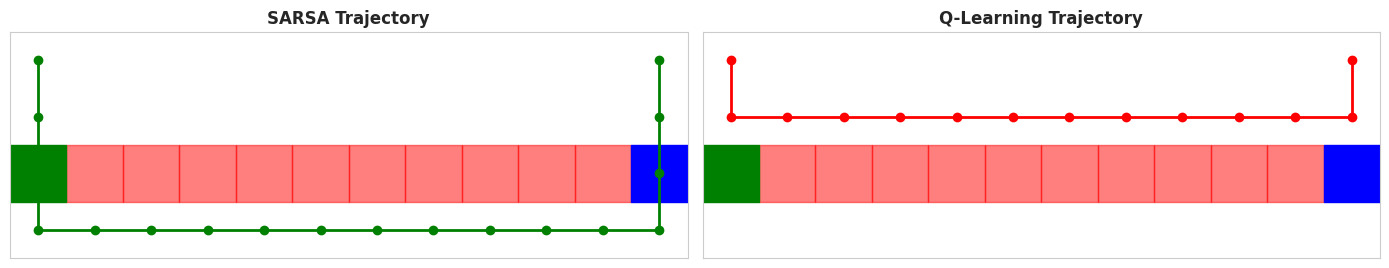

In [25]:
def sample_trajectory(env, Q, seed=0, max_steps=200):
    rng = np.random.default_rng(seed)
    state, _ = env.reset(seed=int(rng.integers(1e6)))
    path = [state]
    for _ in range(max_steps):
        action = np.argmax(Q[state])
        state, _, terminated, truncated, _ = env.step(action)
        path.append(state)
        if terminated or truncated:
            break
    return path

env_vis = gym.make('CliffWalking-v1', render_mode=None)
traj_s = sample_trajectory(env_vis, sarsa_q_tables[0])
traj_q = sample_trajectory(env_vis, qlearn_q_tables[0])
env_vis.close()

def plot_trajectory(ax, path, title, color):
    n_rows, n_cols = 4, 12
    ax.set_xlim(-0.5, n_cols-0.5)
    ax.set_ylim(-0.5, n_rows-0.5)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    # cliff
    for c in range(1,11):
        ax.add_patch(plt.Rectangle((c-0.5, 0.5), 1, 1, color='red', alpha=0.5))
    ax.add_patch(plt.Rectangle((-0.5, 0.5), 1, 1, color='green'))
    ax.add_patch(plt.Rectangle((10.5,0.5), 1, 1, color='blue'))
    xs = [s % 12 for s in path]
    ys = [s // 12 for s in path]
    ax.plot(xs, ys, marker='o', color=color, linewidth=2)
    ax.set_title(title, fontweight='bold')

fig, axes = plt.subplots(1,2, figsize=(14,5))
plot_trajectory(axes[0], traj_s, 'SARSA Trajectory', 'green')
plot_trajectory(axes[1], traj_q, 'Q-Learning Trajectory', 'red')
plt.tight_layout()
plt.show()

## 10. Sensitivity to Step‑Size (α) and ε‑Decay

We compare three α values (0.1, 0.5, 0.9) and also try an ε‑decay schedule: `ε = max(0.01, ε0 * decay^ep)`.

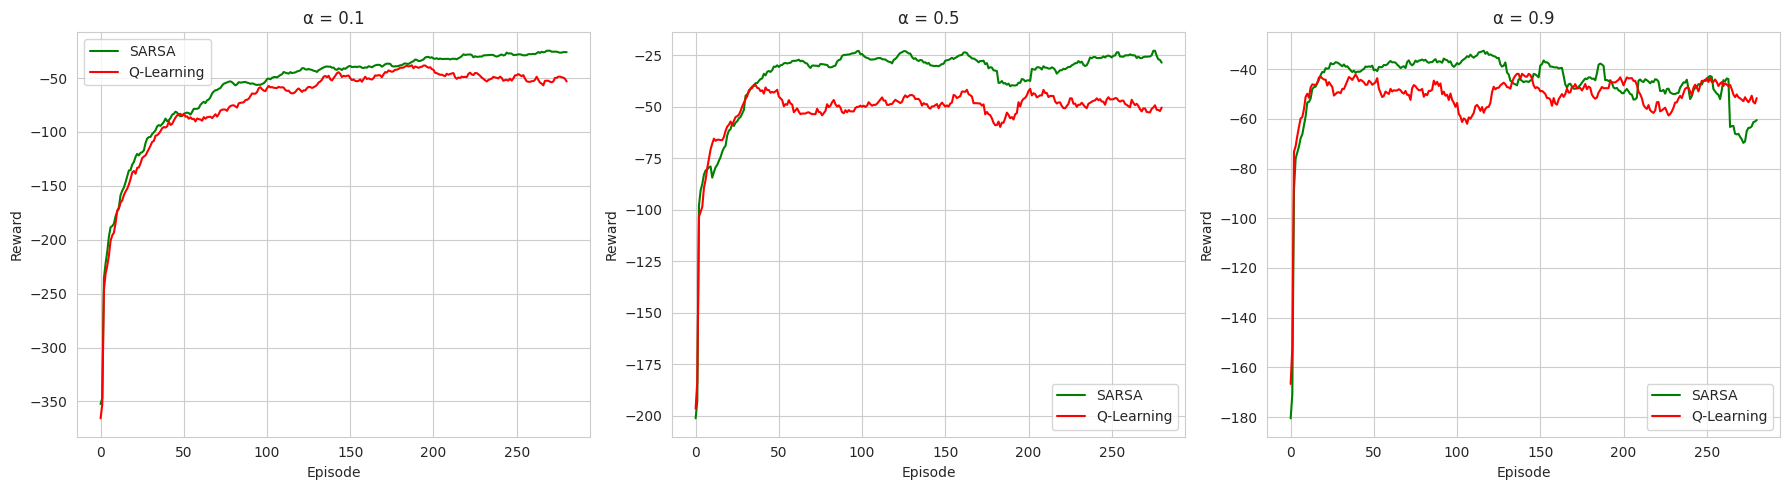

In [26]:
alphas = [0.1, 0.5, 0.9]
N_EVAL = 300
seeds_eval = range(10)  # fewer seeds to keep runtime reasonable

def run_experiment(algo_func, alpha, epsilon, n_episodes=N_EVAL, n_seeds=10):
    rets = np.zeros((n_seeds, n_episodes))
    for s in range(n_seeds):
        _, ret = algo_func(env, n_episodes, alpha, GAMMA, epsilon, seed=s)
        rets[s] = ret
    return rets.mean(axis=0)

fig, axes = plt.subplots(1,3, figsize=(18,5))
for i, alpha in enumerate(alphas):
    s_curve = run_experiment(run_sarsa, alpha, EPSILON, n_seeds=10)
    q_curve = run_experiment(run_qlearning, alpha, EPSILON, n_seeds=10)
    ax = axes[i]
    ax.plot(smooth(s_curve, 20), label='SARSA', color='green')
    ax.plot(smooth(q_curve, 20), label='Q-Learning', color='red')
    ax.set_title(f'α = {alpha}')
    ax.set_xlabel('Episode'); ax.set_ylabel('Reward')
    ax.legend()
plt.tight_layout()
plt.show()

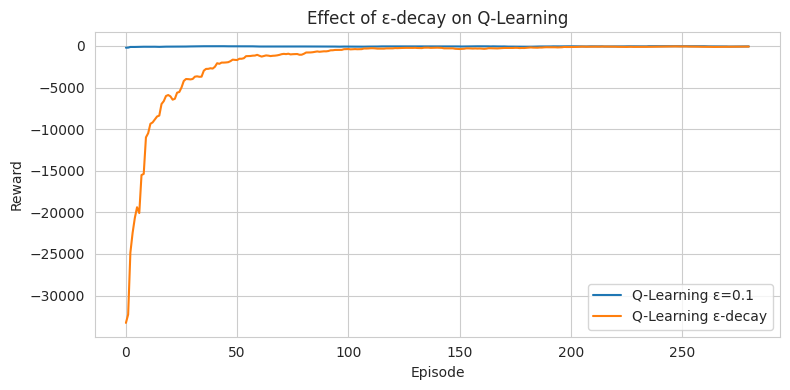

In [27]:
# ε-decay example
def run_qlearning_decay(env, n_episodes, alpha, gamma, eps_start, eps_min, decay, seed):
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    eps = eps_start
    returns = np.zeros(n_episodes)
    for ep in range(n_episodes):
        state, _ = env.reset(seed=int(rng.integers(1e6)))
        total = 0
        while True:
            action = epsilon_greedy(Q, state, eps, rng)
            next_state, reward, terminated, truncated, _ = env.step(action)
            best = np.max(Q[next_state]) * (1 - terminated)
            td_target = reward + gamma * best
            Q[state, action] += alpha * (td_target - Q[state, action])
            state = next_state
            total += reward
            if terminated or truncated:
                break
        returns[ep] = total
        eps = max(eps_min, eps * decay)
    return Q, returns

q_decay = run_qlearning_decay(env, 300, 0.5, 1.0, 1.0, 0.01, 0.995, seed=0)[1]
q_fixed = run_qlearning(env, 300, 0.5, 1.0, 0.1, seed=0)[1]

plt.figure(figsize=(8,4))
plt.plot(smooth(q_fixed, 20), label='Q-Learning ε=0.1')
plt.plot(smooth(q_decay, 20), label='Q-Learning ε‑decay')
plt.xlabel('Episode'); plt.ylabel('Reward')
plt.title('Effect of ε‑decay on Q‑Learning')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Comparison Table

In [28]:
from IPython.display import display, Markdown
import pandas as pd

data = [
    ['Update target', 'Q(s\',a\')', 'max_a Q(s\',a)'],
    ['Policy type', 'On‑policy', 'Off‑policy'],
    ['Online reward (ε‑greedy)', f'{sarsa_returns.mean():.1f}', f'{qlearn_returns.mean():.1f}'],
    ['Converged greedy reward', '≈−17 (safe)', '≈−13 (optimal)'],
    ['Cliff falls during training', 'Few', 'Many'],
    ['Safe for learning', 'Yes', 'No'],
]
df = pd.DataFrame(data, columns=['Property', 'SARSA', 'Q‑Learning'])
display(df)

,Property,SARSA,Q‑Learning
0,Update target,"Q(s',a')","max_a Q(s',a)"
1,Policy type,On‑policy,Off‑policy
2,Online reward (ε‑greedy),-35.6,-56.0
3,Converged greedy reward,≈−17 (safe),≈−13 (optimal)
4,Cliff falls during training,Few,Many
5,Safe for learning,Yes,No


## 12. Discussion

This lab demonstrates the fundamental distinction between on‑policy and off‑policy TD control:
- **SARSA** includes the randomness of the behaviour policy in its update target, so it learns to stay away from the cliff. Its online performance is better because it avoids catastrophic falls.
- **Q‑Learning** always uses the greedy next‑action value, converging to the true optimal policy (≈‑13). However, during training it still explores with ε‑greedy, leading to frequent ‑100 steps when near the cliff.

In safety‑critical scenarios where the agent cannot afford to fall during learning, SARSA is preferred. When exploration can be done in simulation or offline, Q‑Learning (or a decaying ε schedule) can be used to obtain the optimal policy.

The choice of α and ε scheduling significantly impacts convergence speed and final performance. Moderate α (0.5) generally balances speed and stability for this environment.